# Project 2 Code

## Load & Preview Data

In [24]:
# Import the dataset from the ucimlrepo package 
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
concrete_compressive_strength = fetch_ucirepo(id=165) 
  
# data (as pandas dataframes) 
X = concrete_compressive_strength.data.features 
y = concrete_compressive_strength.data.targets 

# variable information 
concrete_compressive_strength.variables

,name,role,type,demographic,description,units,missing_values
0,Cement,Feature,Continuous,None,None,kg/m^3,no
1,Blast Furnace Slag,Feature,Integer,None,None,kg/m^3,no
2,Fly Ash,Feature,Continuous,None,None,kg/m^3,no
3,Water,Feature,Continuous,None,None,kg/m^3,no
4,Superplasticizer,Feature,Continuous,None,None,kg/m^3,no
5,Coarse Aggregate,Feature,Continuous,None,None,kg/m^3,no
6,Fine Aggregate,Feature,Continuous,None,None,kg/m^3,no
7,Age,Feature,Integer,None,None,day,no
8,Concrete compressive strength,Target,Continuous,None,None,MPa,no


In [25]:
# Preview the X dataframe
X.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360


In [6]:
# Preview the y dataframe
y.head()

,Concrete compressive strength
0,79.99
1,61.89
2,40.27
3,41.05
4,44.30


In [27]:
# combined the X and y dataframes for exploration / cleaning
import pandas as pd 

concrete_df = pd.concat([
    concrete_compressive_strength.data.features,
    concrete_compressive_strength.data.targets
], axis=1)

concrete_df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


## Data Cleaning

### 1. Check for outliers or extreme values

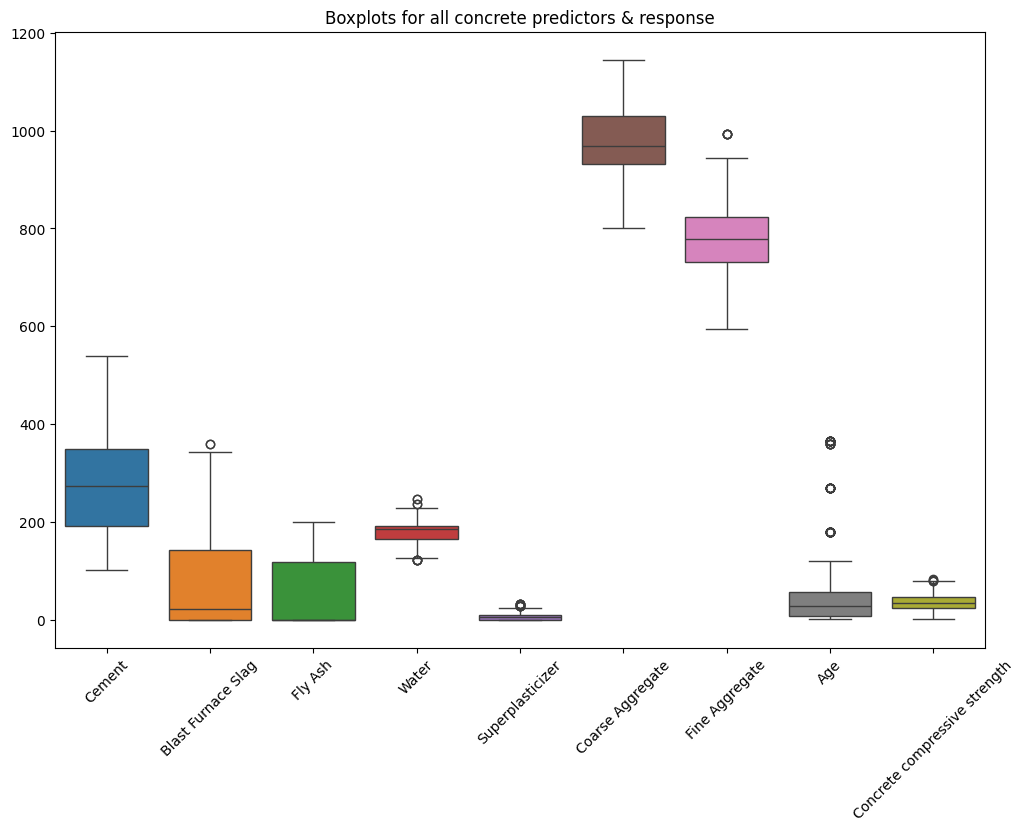

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.boxplot(data=concrete_df)
plt.xticks(rotation=45)
plt.title("Boxplots for all concrete predictors & response")
plt.show()

In [ ]:
# There are a couple of outliers in some of the variables but I think they're fine to keep for now.
# Might need to normalize the variables since the scales differ a lot - for polynomial and splines

### 2. Check for duplicate rows

In [33]:
duplicate_rows = concrete_df[concrete_df.duplicated()]
print("# of duplicate rows:", len(duplicate_rows))

# of duplicate rows: 25


In [34]:
# drop the duplicates, keeping the first occurrence 
concrete_df = concrete_df.drop_duplicates()

In [35]:
# Check that it worked as intended 
duplicate_rows = concrete_df[concrete_df.duplicated()]
print("# of duplicate rows after removing duplicates:", len(duplicate_rows))

# of duplicate rows after removing duplicates: 0


### 3. Check data types

In [36]:
concrete_df.dtypes

Cement                           float64
Blast Furnace Slag               float64
Fly Ash                          float64
Water                            float64
Superplasticizer                 float64
Coarse Aggregate                 float64
Fine Aggregate                   float64
Age                                int64
Concrete compressive strength    float64
dtype: object

In [39]:
concrete_df.Age.astype("float64")

0        28.0
1        28.0
2       270.0
3       365.0
4       360.0
        ...  
1025     28.0
1026     28.0
1027     28.0
1028     28.0
1029     28.0
Name: Age, Length: 1005, dtype: float64

In [40]:
concrete_df.dtypes

Cement                           float64
Blast Furnace Slag               float64
Fly Ash                          float64
Water                            float64
Superplasticizer                 float64
Coarse Aggregate                 float64
Fine Aggregate                   float64
Age                              float64
Concrete compressive strength    float64
dtype: object

### 4. Pairwise scatter plot

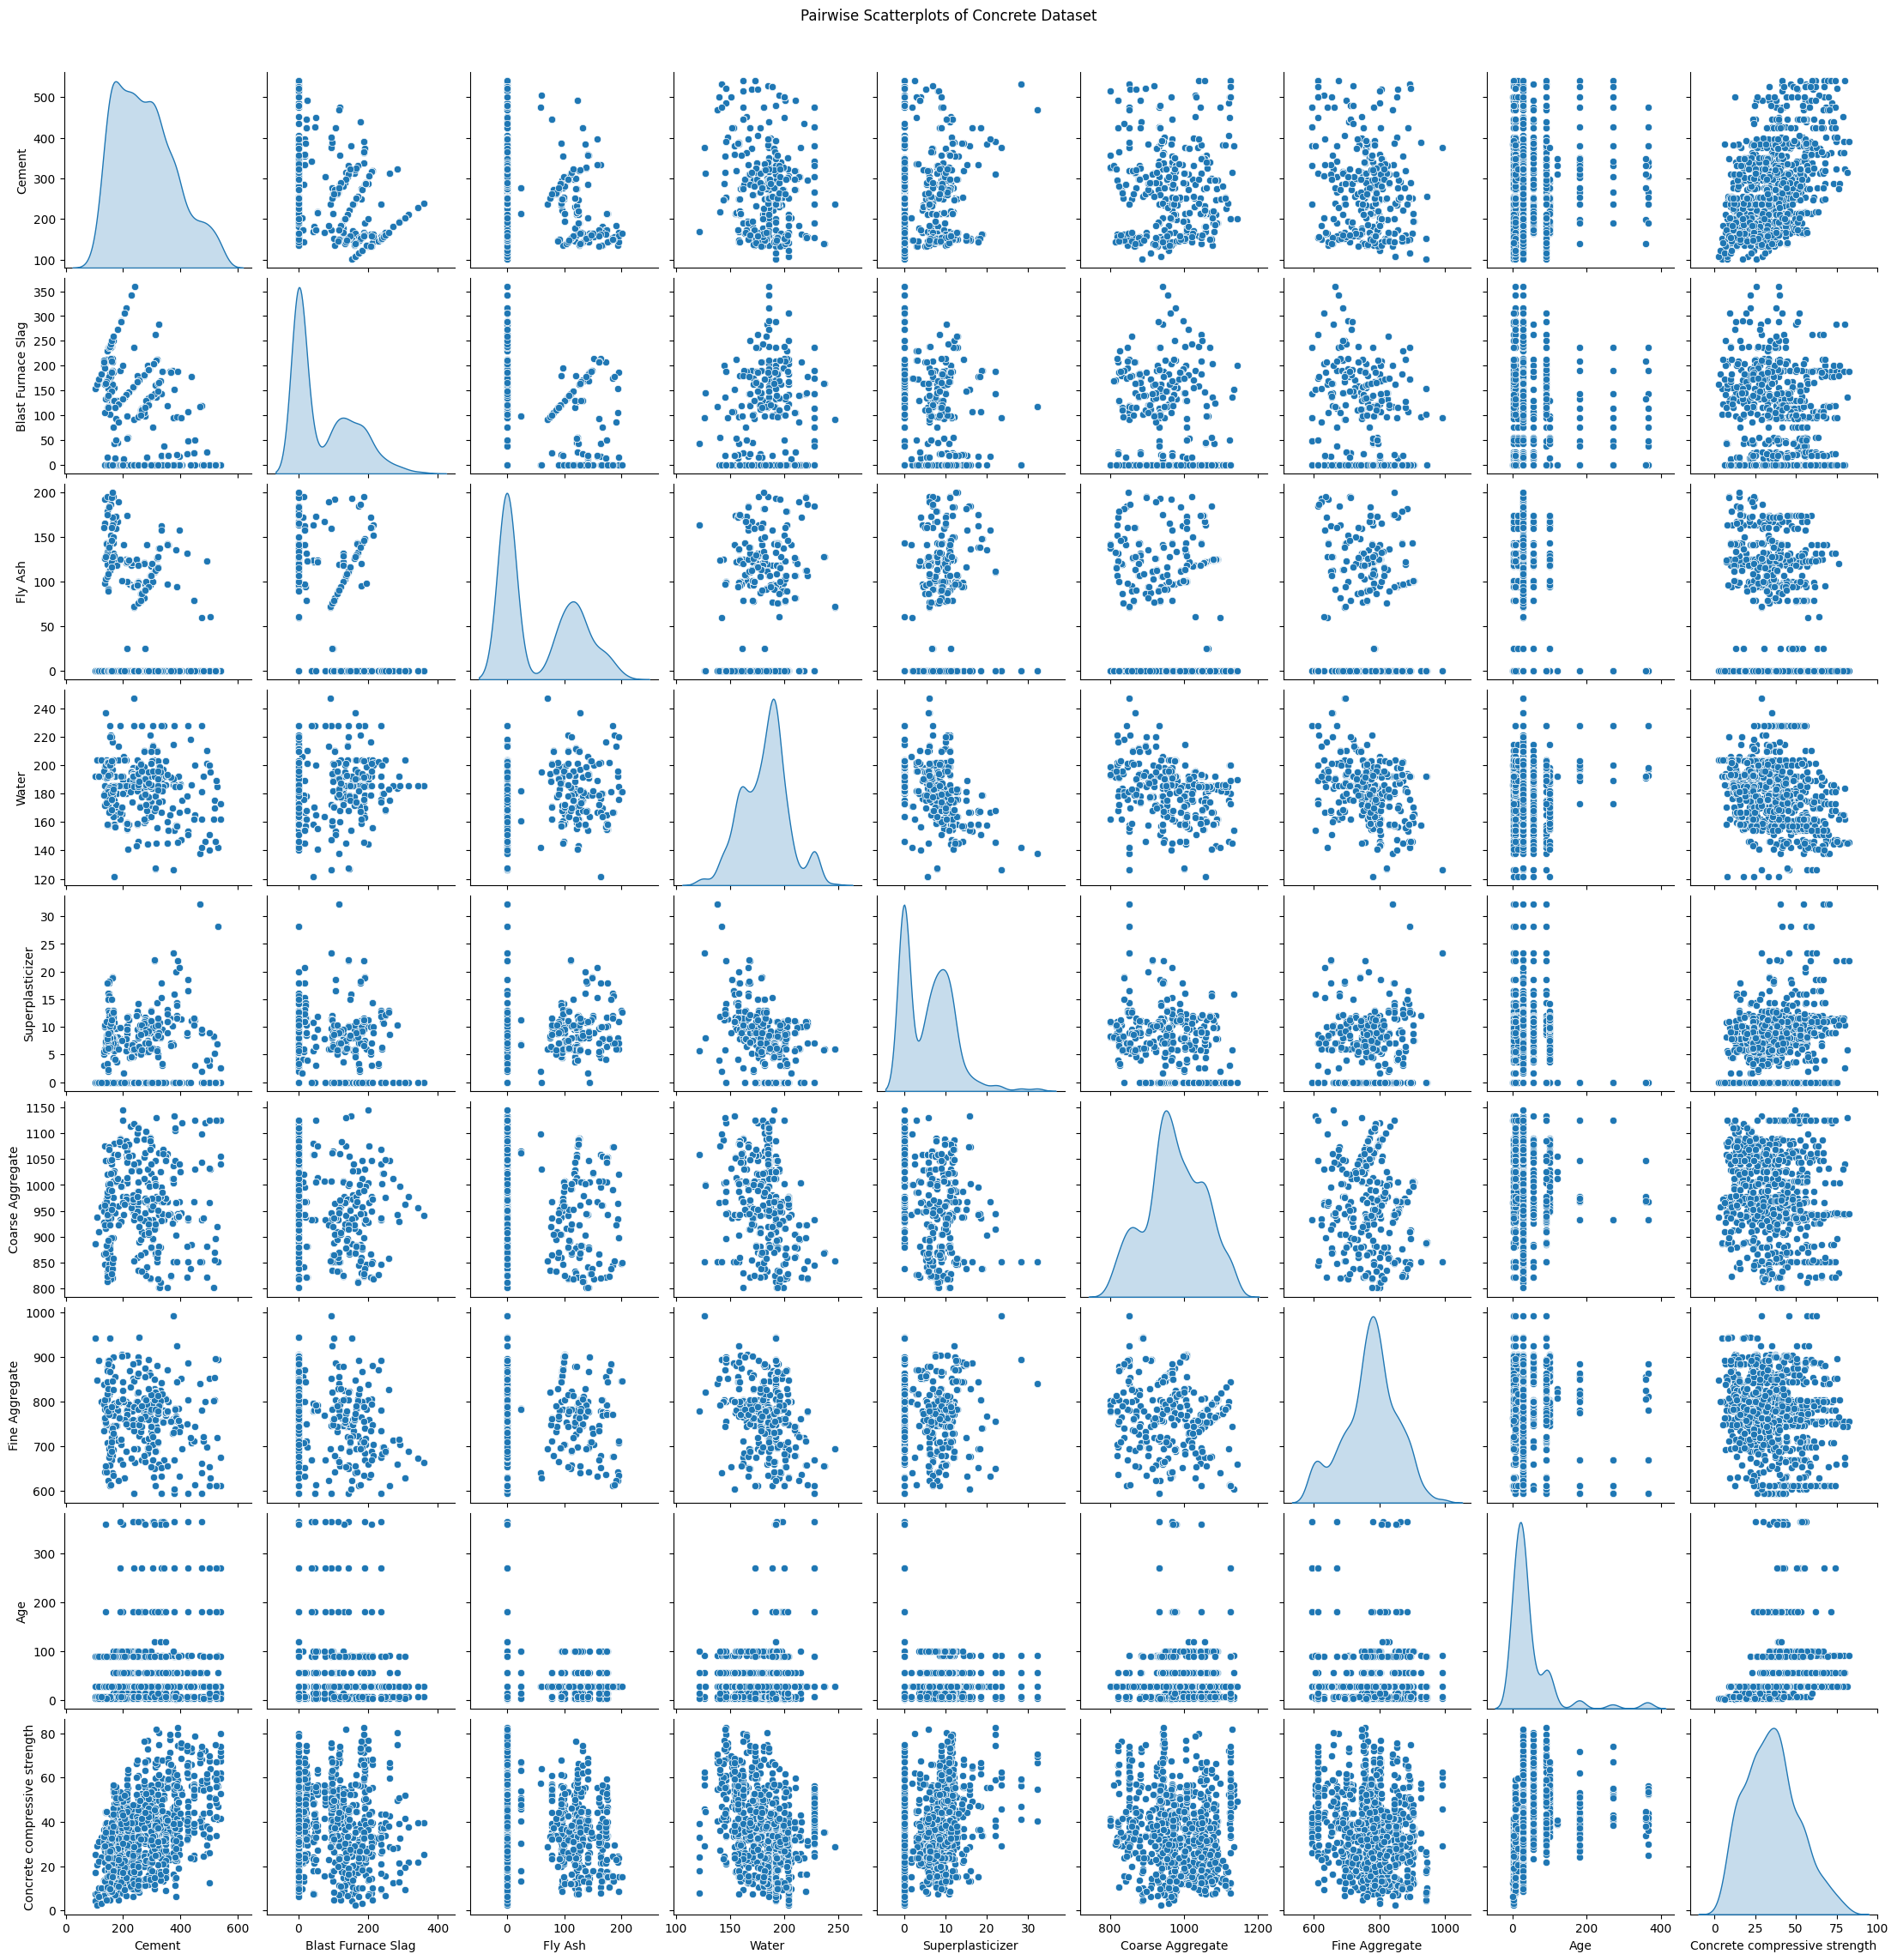

In [42]:
sns.pairplot(concrete_df, diag_kind="kde")
plt.suptitle("Pairwise Scatterplots of Concrete Dataset", y=1.02)
plt.show()


### Summary of findings
| Category          | Concern                                       | Action                                                          |
| ----------------- | --------------------------------------------- | --------------------------------------------------------------- |
| Missing data      | None                                          | ✅ No action                                                     |
| Skewness          | Mild to moderate                              | Consider scaling or log-transforming for regression-type models |
| Outliers          | A few, realistic                              | Keep them                                                       |
| Multicollinearity | Some correlation among ingredients (expected) | OK — trees handle this well; may affect linear models slightly  |


## Train/Test Split

In [43]:
from sklearn.model_selection import train_test_split

X = concrete_df.drop(columns=['Concrete compressive strength'])
y = concrete_df['Concrete compressive strength']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=598
)

## Model Analysis

### 1. Polynomial Regression

In [46]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [47]:
# Fit a polynomial regression with degrees 1-5. 
# Scale the predictors before fitting because there are some skewed predictors. 
# Compare their test MSEs
for d in range(1, 6):
    model = make_pipeline(StandardScaler(), PolynomialFeatures(degree=d, include_bias=False), LinearRegression())
    model.fit(X_train, y_train)
    mse = mean_squared_error(y_test, model.predict(X_test))
    print(f"Degree {d}: Test MSE = {mse:.2f}")


Degree 1: Test MSE = 97.88
Degree 2: Test MSE = 58.07
Degree 3: Test MSE = 53.90
Degree 4: Test MSE = 12207566.33
Degree 5: Test MSE = 1722644.37


### 2. Splines

In [48]:
from sklearn.preprocessing import SplineTransformer

mse_values = []
knots_list = [3, 5, 7, 9, 12]

for k in knots_list:
    spline_model = make_pipeline(
        StandardScaler(),
        SplineTransformer(degree=3, n_knots=k),
        LinearRegression()
    )
    spline_model.fit(X_train, y_train)
    y_pred = spline_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mse_values.append(mse)
    print(f"n_knots={k}: Test MSE = {mse:.2f}")

n_knots=3: Test MSE = 38.13
n_knots=5: Test MSE = 33.91
n_knots=7: Test MSE = 46.76
n_knots=9: Test MSE = 439.29
n_knots=12: Test MSE = 30819.92


### 3. Regression Trees

In [49]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score, GridSearchCV

In [50]:
tree_reg = DecisionTreeRegressor(random_state=598)
tree_reg.fit(X_train, y_train)

y_pred_tree = tree_reg.predict(X_test)
mse_tree = mean_squared_error(y_test, y_pred_tree)

print(f"Unpruned Regression Tree Test MSE: {mse_tree:.2f}")


Unpruned Regression Tree Test MSE: 45.22


In [51]:
param_grid = {
    "max_depth": [2, 4, 6, 8, 10, None],
    "min_samples_leaf": [1, 2, 5, 10]
}

tree_cv = GridSearchCV(
    DecisionTreeRegressor(random_state=598),
    param_grid,
    cv=10,                      
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

tree_cv.fit(X_train, y_train)

,estimator,DecisionTreeR...dom_state=598)
,param_grid,"{'max_depth': [2, 4, ...], 'min_samples_leaf': [1, 2, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [52]:
print("Best parameters:", tree_cv.best_params_)

best_tree = tree_cv.best_estimator_

# Evaluate on test data
y_pred_best_tree = best_tree.predict(X_test)
mse_best_tree = mean_squared_error(y_test, y_pred_best_tree)

print(f"Best Regression Tree Test MSE: {mse_best_tree:.2f}")

Best parameters: {'max_depth': None, 'min_samples_leaf': 2}
Best Regression Tree Test MSE: 48.67


In [53]:
feature_importance = pd.Series(best_tree.feature_importances_, index=X_train.columns)
print(feature_importance.sort_values(ascending=False))

Cement                0.371943
Age                   0.329646
Blast Furnace Slag    0.112071
Water                 0.074690
Superplasticizer      0.048068
Coarse Aggregate      0.030067
Fine Aggregate        0.027802
Fly Ash               0.005713
dtype: float64


### 4. Random Forest 

In [55]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold

In [61]:
n_estimators_list = [100, 300, 500]         # 100 trees is usually fine
max_features_list = [1, 2, 3, 4, 5, 6, 7, 8]       # 8 features
max_depth_list = [None, 5, 10, 20]         # None = unpruned
min_samples_leaf_list = [1, 2, 4]          # prevent overfitting

In [63]:
# Cross validation 
kf = KFold(n_splits=5, shuffle=True, random_state=42)

best_mse = float('inf')
best_params = {}
results = []

for n_estimators in n_estimators_list:
    for max_features in max_features_list:
        for max_depth in max_depth_list:
            for min_samples_leaf in min_samples_leaf_list:
                rf = RandomForestRegressor(
                    n_estimators=n_estimators,
                    max_features=max_features,
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    random_state=598
                )
                
                # CV MSE
                cv_mse = -cross_val_score(rf, X_train, y_train,
                                          cv=kf, scoring='neg_mean_squared_error').mean()
                
                # Save results
                results.append({
                    'n_estimators': n_estimators,
                    'max_features': max_features,
                    'max_depth': max_depth,
                    'min_samples_leaf': min_samples_leaf,
                    'CV_MSE': cv_mse
                })
                
                # Track best
                if cv_mse < best_mse:
                    best_mse = cv_mse
                    best_params = {
                        'n_estimators': n_estimators,
                        'max_features': max_features,
                        'max_depth': max_depth,
                        'min_samples_leaf': min_samples_leaf
                    }

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Sort by CV_MSE for readability
results_df = results_df.sort_values(by='CV_MSE').reset_index(drop=True)

# Display top 10 rows
print("Top 10 hyperparameter combinations by CV MSE:")
results_df.head(10)

Top 10 hyperparameter combinations by CV MSE:


,n_estimators,max_features,max_depth,min_samples_leaf,CV_MSE
0,500,7,20.0,1,30.323921
1,500,6,20.0,1,30.340130
2,500,6,NaN,1,30.351989
3,500,7,NaN,1,30.355344
4,300,7,20.0,1,30.437276
5,300,7,NaN,1,30.438082
6,300,6,20.0,1,30.540583
7,500,5,20.0,1,30.550485
8,500,5,NaN,1,30.554346
9,300,6,NaN,1,30.580008


In [64]:
# Use the best hyperparameters found during CV
final_rf = RandomForestRegressor(
    **best_params,
    random_state=598
)
final_rf.fit(X_train, y_train)
y_pred = final_rf.predict(X_test)
test_mse = mean_squared_error(y_test, y_pred)
print("Test MSE for final random forest:", test_mse)



Test MSE for final random forest: 23.53380728864762
